In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

np.random.seed(42)

In [2]:
n = 500

industries = ['IT', 'Finance', 'Healthcare', 'Education', 'Retail']
company_sizes = ['Small', 'Medium', 'Large']
ai_tools = ['ChatGPT', 'GitHub Copilot', 'Gemini', 'Claude', 'Midjourney']

df = pd.DataFrame({
    'Organization_ID': range(1, n+1),
    'Industry': np.random.choice(industries, n),
    'Company_Size': np.random.choice(company_sizes, n),
    'Employee_Count': np.random.randint(20, 5000, n),
    'AI_Tool': np.random.choice(ai_tools, n),
    'Adoption_Year': np.random.randint(2020, 2026, n),
    'AI_Investment': np.random.randint(5000, 500000, n),
    'Productivity_Gain': np.random.uniform(5, 50, n),
    'Cost_Savings': np.random.randint(1000, 700000, n),
    'Satisfaction_Score': np.random.uniform(1, 10, n)
})

df['Adoption_Level'] = pd.cut(
    df['Productivity_Gain'],
    bins=[0, 20, 35, 100],
    labels=['Low', 'Medium', 'High']
)

df.head()

,Organization_ID,Industry,Company_Size,Employee_Count,AI_Tool,Adoption_Year,AI_Investment,Productivity_Gain,Cost_Savings,Satisfaction_Score,Adoption_Level
0,1,Education,Medium,2580,Gemini,2023,82794,11.844693,369266,4.568983,Low
1,2,Retail,Small,3411,GitHub Copilot,2024,297985,24.814554,235104,2.185435,Medium
2,3,Healthcare,Medium,2985,Claude,2024,129447,32.688411,544296,8.787662,Medium
3,4,Retail,Small,3663,Gemini,2025,125029,8.755884,203346,2.415459,Low
4,5,Retail,Large,3870,Midjourney,2022,184830,44.708737,557690,3.788091,High


In [3]:
df.to_csv("ai_adoption.csv", index=False)
print("Dataset Saved Successfully")

Dataset Saved Successfully


In [4]:
df.shape

(500, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Organization_ID     500 non-null    int64   
 1   Industry            500 non-null    object  
 2   Company_Size        500 non-null    object  
 3   Employee_Count      500 non-null    int64   
 4   AI_Tool             500 non-null    object  
 5   Adoption_Year       500 non-null    int64   
 6   AI_Investment       500 non-null    int64   
 7   Productivity_Gain   500 non-null    float64 
 8   Cost_Savings        500 non-null    int64   
 9   Satisfaction_Score  500 non-null    float64 
 10  Adoption_Level      500 non-null    category
dtypes: category(1), float64(2), int64(5), object(3)
memory usage: 39.8+ KB


In [6]:
df.isnull().sum()

,0
Organization_ID,0
Industry,0
Company_Size,0
Employee_Count,0
AI_Tool,0
Adoption_Year,0
AI_Investment,0
Productivity_Gain,0
Cost_Savings,0
Satisfaction_Score,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.describe()

,Organization_ID,Employee_Count,Adoption_Year,AI_Investment,Productivity_Gain,Cost_Savings,Satisfaction_Score
count,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,2588.09200,2022.540000,236271.848000,27.379781,348356.412000,5.455104
std,144.481833,1421.24173,1.701231,142165.889019,12.909313,192311.190896,2.544363
min,1.000000,22.00000,2020.000000,5781.000000,5.006061,3257.000000,1.017929
25%,125.750000,1337.00000,2021.000000,115885.000000,17.423108,182436.750000,3.247479
50%,250.500000,2690.50000,2023.000000,228560.000000,27.439693,354030.000000,5.634726
75%,375.250000,3753.50000,2024.000000,356276.000000,38.326240,497273.500000,7.506228
max,500.000000,4991.00000,2025.000000,498253.000000,49.901939,695489.000000,9.990034


In [13]:
df['Organization_ID'].nunique()

500

In [14]:
df['AI_Tool'].value_counts()

,count
AI_Tool,
Claude,106
Midjourney,103
GitHub Copilot,103
ChatGPT,96
Gemini,92


In [15]:
df['Industry'].value_counts()

,count
Industry,
Education,112
IT,109
Finance,95
Retail,93
Healthcare,91


In [16]:
df['Productivity_Gain'].mean()

np.float64(27.379780963279458)

In [17]:
df['Productivity_Gain'].median()

27.439693044988196

In [18]:
df['Productivity_Gain'].std()

12.909313374345068

In [19]:
df['Productivity_Gain'].quantile([0.25,0.50,0.75])

,Productivity_Gain
0.25,17.423108
0.50,27.439693
0.75,38.326240


In [20]:
df.groupby('Industry')['Productivity_Gain'].mean()

,Productivity_Gain
Industry,
Education,27.451730
Finance,27.556870
Healthcare,27.341943
IT,26.635983
Retail,28.021023


In [21]:
df['Company_Size'].value_counts()

,count
Company_Size,
Small,175
Medium,166
Large,159


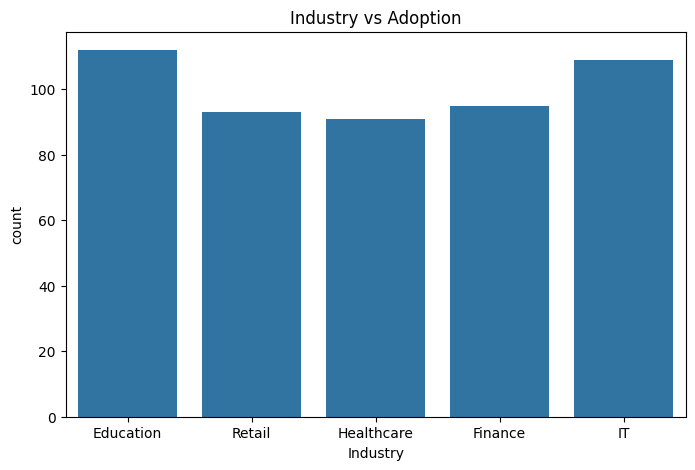

In [22]:
plt.figure(figsize=(8,5))
sns.countplot(x='Industry', data=df)
plt.title("Industry vs Adoption")
plt.show()

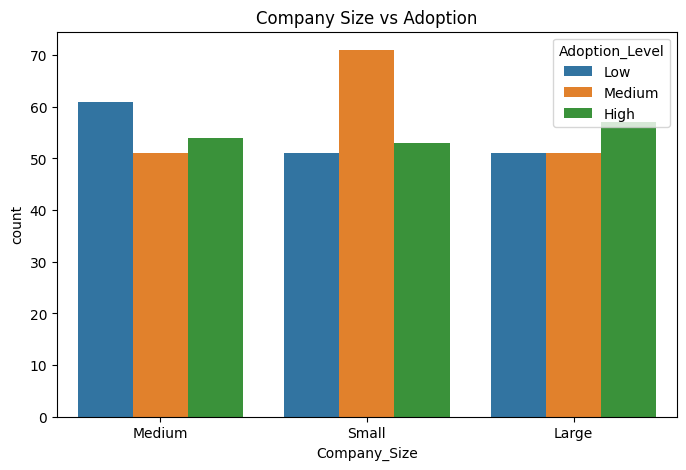

In [23]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='Company_Size',
    hue='Adoption_Level',
    data=df
)
plt.title("Company Size vs Adoption")
plt.show()

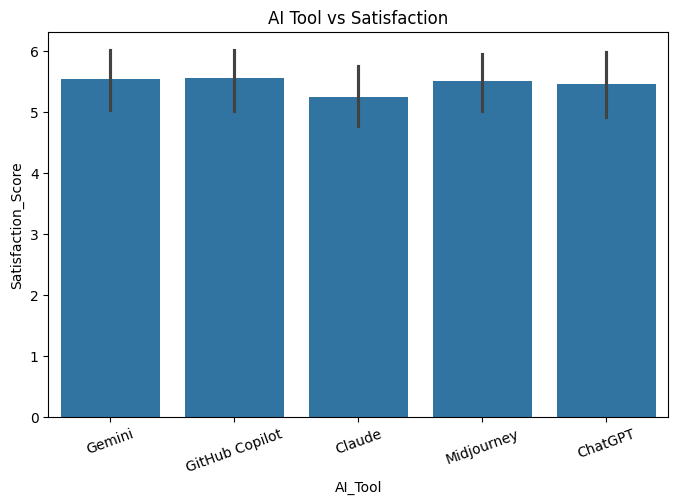

In [24]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='AI_Tool',
    y='Satisfaction_Score',
    data=df
)
plt.title("AI Tool vs Satisfaction")
plt.xticks(rotation=20)
plt.show()

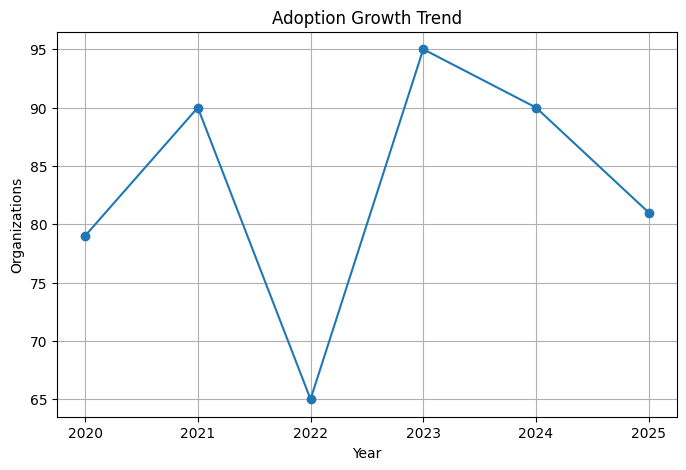

In [25]:
yearly_growth = df.groupby('Adoption_Year').size()

plt.figure(figsize=(8,5))
plt.plot(
    yearly_growth.index,
    yearly_growth.values,
    marker='o'
)

plt.title("Adoption Growth Trend")
plt.xlabel("Year")
plt.ylabel("Organizations")
plt.grid(True)
plt.show()

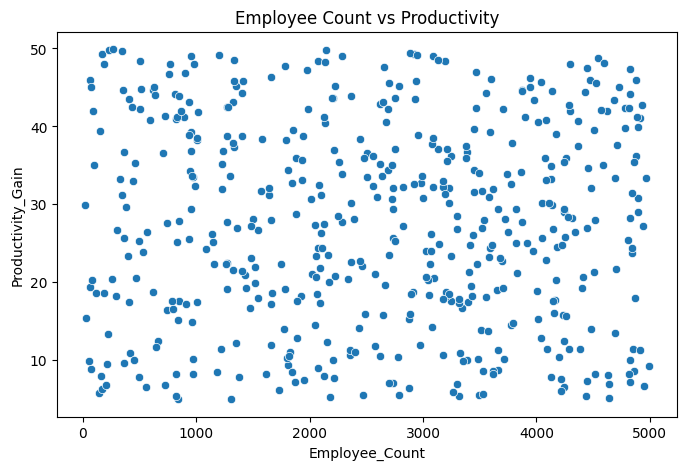

In [26]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Employee_Count',
    y='Productivity_Gain',
    data=df
)
plt.title("Employee Count vs Productivity")
plt.show()

In [27]:
corr = df[
    ['Employee_Count',
     'AI_Investment',
     'Productivity_Gain',
     'Cost_Savings',
     'Satisfaction_Score']
]

corr_matrix = corr.corr()
corr_matrix

,Employee_Count,AI_Investment,Productivity_Gain,Cost_Savings,Satisfaction_Score
Employee_Count,1.000000,-0.027661,-0.020749,0.002117,0.001801
AI_Investment,-0.027661,1.000000,0.016508,-0.031107,0.014919
Productivity_Gain,-0.020749,0.016508,1.000000,0.032428,0.029963
Cost_Savings,0.002117,-0.031107,0.032428,1.000000,0.050119
Satisfaction_Score,0.001801,0.014919,0.029963,0.050119,1.000000


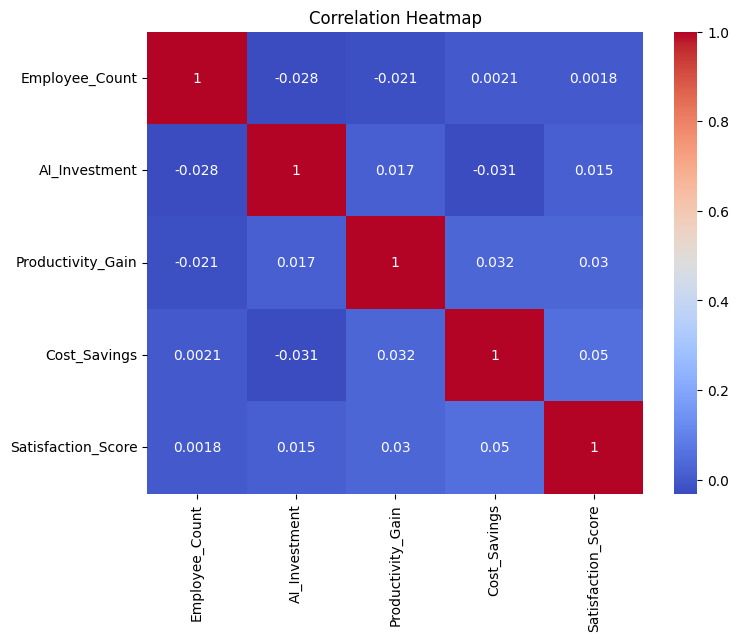

In [28]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

In [30]:
small = df[df['Company_Size']=='Small']['Productivity_Gain']
medium = df[df['Company_Size']=='Medium']['Productivity_Gain']
large = df[df['Company_Size']=='Large']['Productivity_Gain']

In [31]:
f_stat, p_value = f_oneway(
    small,
    medium,
    large
)

print("F Statistic =", f_stat)
print("P Value =", p_value)

F Statistic = 0.8027837475006232
P Value = 0.4486600388875541


In [32]:
if p_value < 0.05:
    print("Reject H0")
    print("Company size significantly impacts AI adoption.")
else:
    print("Fail to Reject H0")
    print("Company size has no significant impact.")

Fail to Reject H0
Company size has no significant impact.


In [33]:
ai_leaders = df[
    (df['Adoption_Level']=='High') &
    (df['Satisfaction_Score']>=8)
]

ai_leaders.head()

,Organization_ID,Industry,Company_Size,Employee_Count,AI_Tool,Adoption_Year,AI_Investment,Productivity_Gain,Cost_Savings,Satisfaction_Score,Adoption_Level
13,14,Finance,Large,620,ChatGPT,2024,20997,44.686749,134296,9.154784,High
44,45,Finance,Medium,1274,ChatGPT,2022,62804,38.697185,474958,9.823319,High
48,49,Finance,Medium,2617,Gemini,2024,72260,42.865140,592202,9.736089,High
82,83,Retail,Medium,2369,ChatGPT,2024,246130,43.905362,280067,8.794861,High
98,99,Finance,Large,3197,Gemini,2022,113777,48.326466,242225,9.618229,High


In [34]:
early_adopters = df[
    df['Adoption_Year'] <= 2022
]

early_adopters.head()

,Organization_ID,Industry,Company_Size,Employee_Count,AI_Tool,Adoption_Year,AI_Investment,Productivity_Gain,Cost_Savings,Satisfaction_Score,Adoption_Level
4,5,Retail,Large,3870,Midjourney,2022,184830,44.708737,557690,3.788091,High
5,6,Finance,Large,892,GitHub Copilot,2021,343416,41.162159,185456,3.610410,High
12,13,Retail,Medium,4247,Midjourney,2022,392732,12.467970,92218,8.495473,Low
15,16,Finance,Medium,2156,Midjourney,2022,103605,12.300503,519767,7.066179,Low
16,17,Education,Large,2469,Midjourney,2021,422127,5.567338,180767,1.466522,Low


In [36]:
slow_adopters = df[
    df['Adoption_Level']=='Low'
]

slow_adopters.head()

,Organization_ID,Industry,Company_Size,Employee_Count,AI_Tool,Adoption_Year,AI_Investment,Productivity_Gain,Cost_Savings,Satisfaction_Score,Adoption_Level
0,1,Education,Medium,2580,Gemini,2023,82794,11.844693,369266,4.568983,Low
3,4,Retail,Small,3663,Gemini,2025,125029,8.755884,203346,2.415459,Low
12,13,Retail,Medium,4247,Midjourney,2022,392732,12.467970,92218,8.495473,Low
15,16,Finance,Medium,2156,Midjourney,2022,103605,12.300503,519767,7.066179,Low
16,17,Education,Large,2469,Midjourney,2021,422127,5.567338,180767,1.466522,Low


In [37]:
high_roi = df[
    df['Cost_Savings'] >
    df['AI_Investment']
]

high_roi.head()

,Organization_ID,Industry,Company_Size,Employee_Count,AI_Tool,Adoption_Year,AI_Investment,Productivity_Gain,Cost_Savings,Satisfaction_Score,Adoption_Level
0,1,Education,Medium,2580,Gemini,2023,82794,11.844693,369266,4.568983,Low
2,3,Healthcare,Medium,2985,Claude,2024,129447,32.688411,544296,8.787662,Medium
3,4,Retail,Small,3663,Gemini,2025,125029,8.755884,203346,2.415459,Low
4,5,Retail,Large,3870,Midjourney,2022,184830,44.708737,557690,3.788091,High
6,7,Healthcare,Small,1272,GitHub Copilot,2025,42643,27.734305,400009,8.842726,Medium


In [38]:
print("AI Leaders:", len(ai_leaders))
print("Early Adopters:", len(early_adopters))
print("Slow Adopters:", len(slow_adopters))
print("High ROI:", len(high_roi))

AI Leaders: 32
Early Adopters: 234
Slow Adopters: 163
High ROI: 326


In [39]:
df['AI_Tool'].value_counts().idxmax()
df['Industry'].value_counts().idxmax()
df.groupby('AI_Tool')['Satisfaction_Score'].mean().sort_values(ascending=False)
df.groupby('Industry')['Productivity_Gain'].mean().sort_values(ascending=False)

,Productivity_Gain
Industry,
Retail,28.021023
Finance,27.556870
Education,27.451730
Healthcare,27.341943
IT,26.635983


In [40]:
print("1. Increase investment in high ROI AI tools.")
print("2. Focus on employee AI training.")
print("3. Encourage AI adoption in low-performing industries.")
print("4. Monitor satisfaction scores regularly.")
print("5. Scale successful AI implementations across departments.")

1. Increase investment in high ROI AI tools.
2. Focus on employee AI training.
3. Encourage AI adoption in low-performing industries.
4. Monitor satisfaction scores regularly.
5. Scale successful AI implementations across departments.
